In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

In [3]:
def spoke_split(kspacedata, coords):
    halfwaypoint = kspacedata.shape[0] // 2
    
    spoke_a = np.flip(kspacedata[:halfwaypoint], axis=0)
    spoke_b = kspacedata[halfwaypoint:]
    
    coords_a = np.flip(coords[:halfwaypoint, :], axis=0)
    coords_b = coords[halfwaypoint:, :]
    
    return spoke_a, spoke_b, coords_a, coords_b

def get_spoke_b_index(spoke_index, n_spokes):
    return n_spokes + spoke_index

def spoke_remove(kspacedata, coord_data, unsampling):
    return kspacedata[:,::unsampling], coord_data[::unsampling]

def point_remove(kspacedata, coord_data, n):
    return kspacedata[:,:,n:], coord_data[:,n:,:]


def generate_zte_data(ksp, coord,n_missing,undersampling_factor=1):

    n_spokes, n_points, n_dims = coord.shape
    n_coils = ksp.shape[0]
    half = n_points // 2

    ksp_new = np.zeros((n_coils,n_spokes * 2, half), dtype=ksp.dtype)
    coord_new = np.zeros((n_spokes * 2, half, n_dims), dtype=coord.dtype)
    
    for coil_index in range(n_coils):
        for spoke_index in range(n_spokes):
            spoke_a, spoke_b, coords_a, coords_b = spoke_split(ksp[coil_index,spoke_index], coord[spoke_index])
            
            b_index = get_spoke_b_index(spoke_index, n_spokes)

            ksp_new[coil_index, spoke_index] = spoke_a
            ksp_new[coil_index,b_index] = spoke_b

            coord_new[spoke_index] = coords_a
            coord_new[b_index] = coords_b

    ksp_new, coord_new = point_remove(kspacedata=ksp_new, coord_data=coord_new, n=n_missing)
    ksp_new, coord_new = spoke_remove(kspacedata=ksp_new, coord_data=coord_new, unsampling=undersampling_factor)

    return ksp_new, coord_new

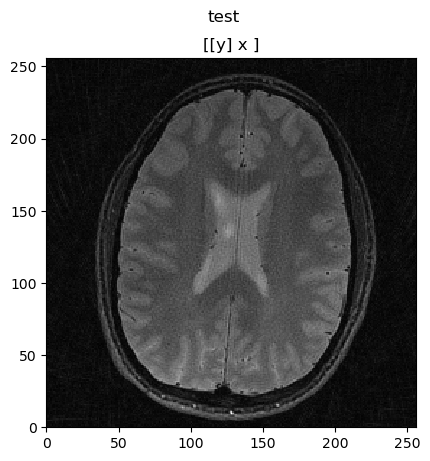

In [4]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=0, undersampling_factor=1)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)
img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss, title='test')

## Goal: Plot ZTE Trajectory 

**Objectives:**

1. Create x and y arrays of data with specified gapsize
2. Plot with scatter
3. Call hankel with specified gap size

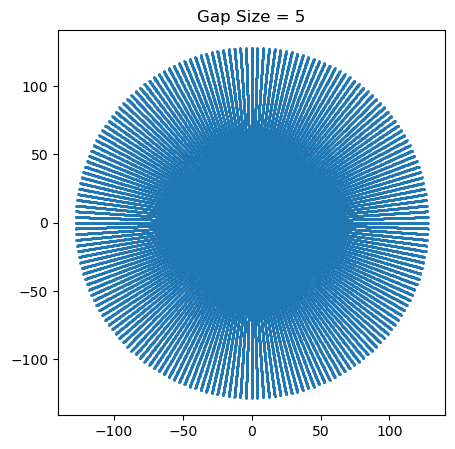

In [5]:
x_radial_zte, y_radial_zte = zte_radial_coords[:,:,0], zte_radial_coords[:,:,1]

plt.figure(figsize=(5,5))

plt.scatter(x_radial_zte, y_radial_zte, s=1)
plt.title('Gap Size = 5')
plt.show()

## Goal: Plot ZTE Trajectory with pl.ImagePlot

**Objectives:**

1. Create Empty Grid of gridsize 256x256
2. Normalise
3. Plot

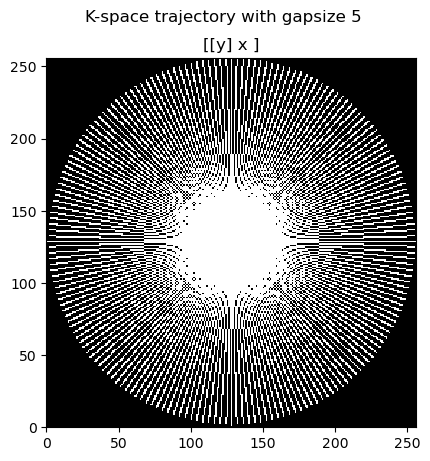

In [6]:
grid_size = 256
trajectory_grid = np.zeros((grid_size, grid_size))

kx_norm, ky_norm = (x_radial_zte / x_radial_zte.max()).astype(int), (y_radial_zte / y_radial_zte.max()).astype(int)
# Step 1: normalise to [-1, 1]
kx_norm = x_radial_zte / np.abs(x_radial_zte).max()
ky_norm = y_radial_zte / np.abs(y_radial_zte).max()

# Step 2: scale to pixel range
kx_norm = kx_norm * (grid_size // 2 - 1)
ky_norm = ky_norm * (grid_size // 2 - 1)

# Step 3: truncate to integer indices
kx_norm = kx_norm.astype(int)
ky_norm = ky_norm.astype(int)

# Step 4: shift origin to array centre
kx_norm = kx_norm + grid_size // 2
ky_norm = ky_norm + grid_size // 2

trajectory_grid[ky_norm, kx_norm] = 1
pl.ImagePlot(trajectory_grid, title='K-space trajectory with gapsize 5')

## Goal: Plot Trajectory and colourcode acquisition order

**Objectives:**

1. Assign colour to each n spokes (i.e. bin them)
2. Plot coords and see spoke trajectory


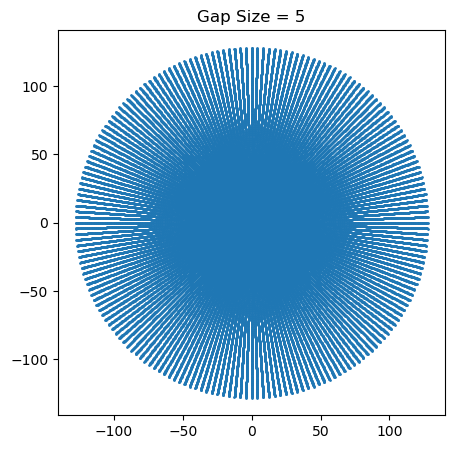

In [25]:
x_diam, y_diam = coord[:,:,0], coord[:,:,1]

plt.figure(figsize=(5,5))

plt.scatter(x_diam, y_diam, s=1)
plt.title('Gap Size = 5')
plt.show()

In [38]:
coord[0]

array([[ 1.28000000e+02, -1.56754803e-14],
       [ 1.27499023e+02, -1.56141275e-14],
       [ 1.26998034e+02, -1.55527746e-14],
       ...,
       [-1.26998034e+02,  1.55527746e-14],
       [-1.27499023e+02,  1.56141275e-14],
       [-1.28000000e+02,  1.56754803e-14]])

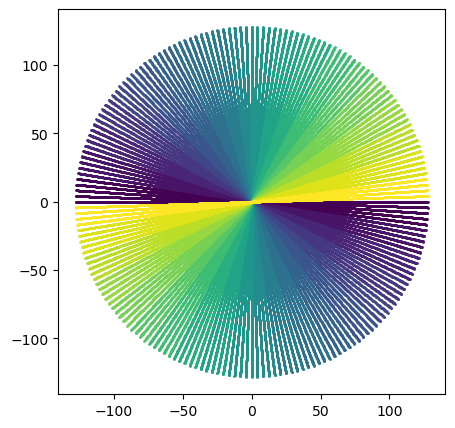

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

x_diam, y_diam = coord[:,:,0], coord[:,:,1]

n_spokes = coord.shape[0]
n_bins = 20
bin_indices = np.floor(np.arange(n_spokes) / n_spokes * n_bins).astype(int)

colours = cm.viridis(np.linspace(0, 1, n_bins))

plt.figure(figsize=(5,5))
for b in range(n_bins):
    mask = bin_indices == b
    plt.scatter(x_diam[mask], y_diam[mask], s=1, color=colours[b])

plt.show()

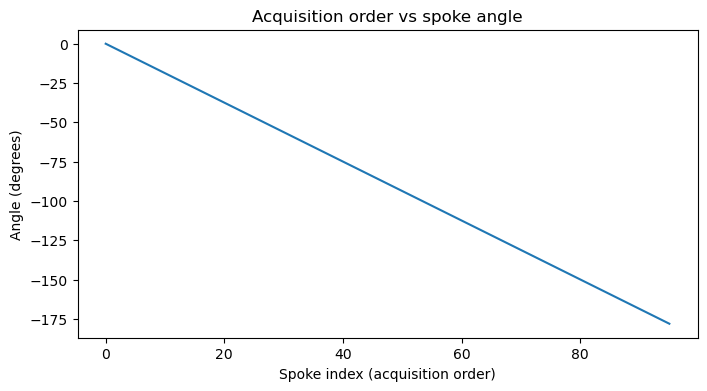

In [ ]:
angles = np.arctan2(coord[:, 0, 1], coord[:, 0, 0])

plt.figure(figsize=(8, 4))
plt.plot(np.arange(n_spokes), np.degrees(angles), '-')
plt.xlabel('Spoke index (acquisition order)')
plt.ylabel('Angle (degrees)')
plt.title('Acquisition order vs spoke angle')
plt.show()

## Goal: Plot kspace values with matplotlib and colourbar

**Objectives:**

1. Reshape coords into 1x2->N array
2. Rehsape kspace into 1 -> N array
3. Plot with `plt.scatter` and `plt.colourbar`

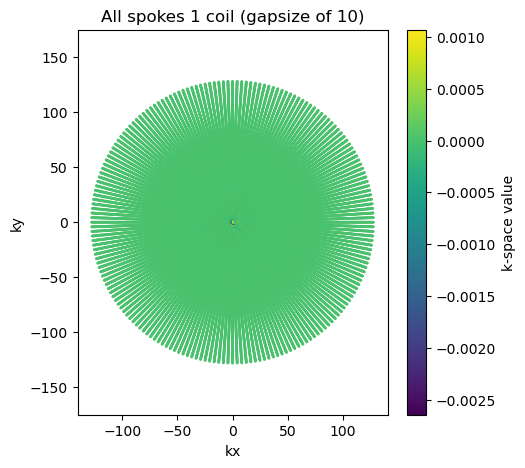

In [7]:
all_coords = zte_radial_coords.reshape(-1, 2)
all_ksp    = zte_radial_kspace[0].reshape(-1)

plt.figure(figsize=(5, 5))
plt.scatter(all_coords[:, 0], all_coords[:, 1],c=np.real(all_ksp),s=1)
plt.colorbar(label='k-space value')
plt.title('All spokes 1 coil (gapsize of 10)')
plt.xlabel('kx')
plt.ylabel('ky')
plt.axis('equal')

plt.show()

## Goal: Grid the radial data onto a cartesian grid

1. use interp and gridding
- Problem: **sp.gridding assumes coords run from -N/2 to N/2. Mine run from 0 to norm(N/2)**
- Solution: Undo spoke splitting
2. use nufft



### First try to repeat above graph but underhood we are plotting diam spokes not radial

**Note:** This did nothing until I added the following line
`diam_coords = diam_coords + 128`

gridding (and interpolate) assume that the first point is the last one

**Alternatively** use `np.fft.fftshift(kspace)`

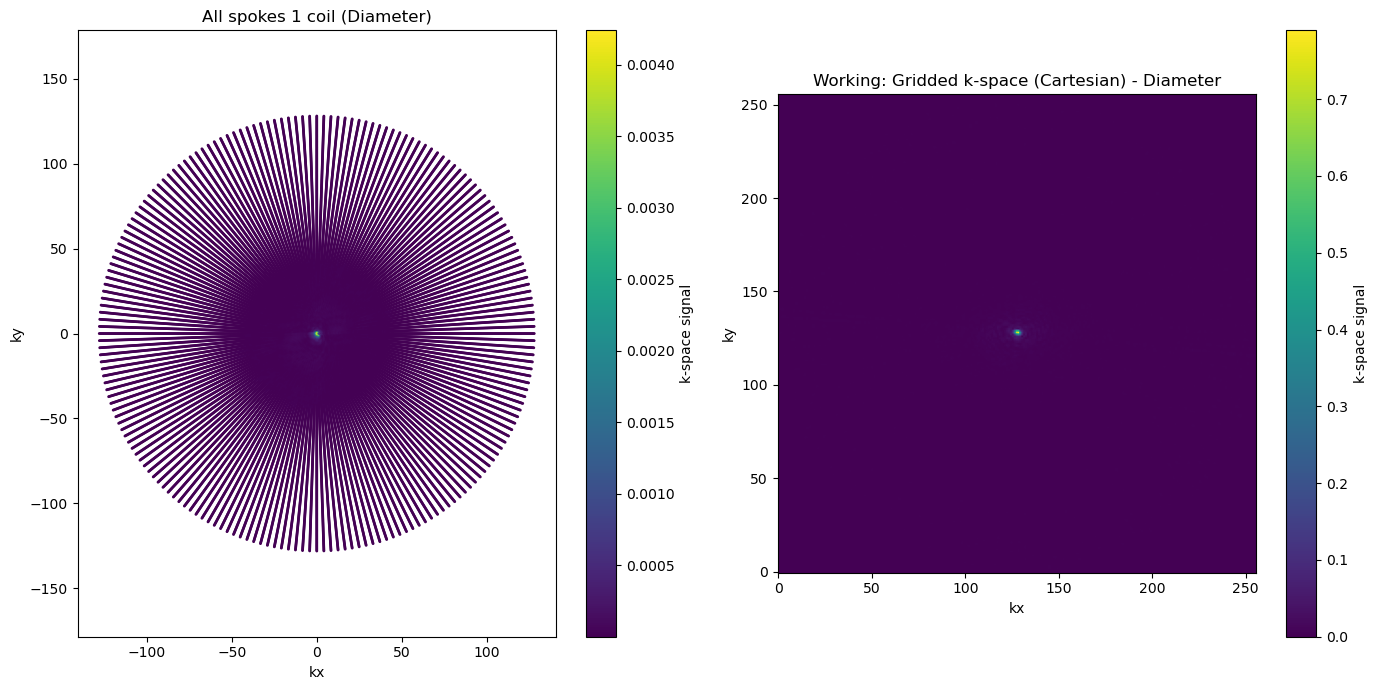

In [ ]:
def spoke_combine(kspacedata, coords):
    n_spokes = kspacedata.shape[1] // 2
    combined_kspace = []
    combined_coords = []
    
    for i in range(n_spokes):
        spoke_a = np.flip(kspacedata[:, i, :], axis=1)
        spoke_b = kspacedata[:, i + n_spokes, :]
        combined_kspace.append(np.concatenate([spoke_a, spoke_b], axis=1))
        
        coord_a = np.flip(coords[i, :], axis=0)
        coord_b = coords[i + n_spokes, :]
        combined_coords.append(np.concatenate([coord_a, coord_b], axis=0))
    
    return np.stack(combined_kspace, axis=1), np.stack(combined_coords, axis=0)
diam_kspace, diam_coords = spoke_combine(kspacedata = zte_radial_kspace, coords=zte_radial_coords)

dcf_diam = np.sqrt(diam_coords[..., 0]**2 + diam_coords[...,1]**2)
all_coords_diam = diam_coords.reshape(-1, 2)
all_ksp_diam    = diam_kspace[0].reshape(-1)


one_coil_diam = diam_kspace[0]
dcf = np.sqrt(diam_coords[..., 0]**2 + diam_coords[...,1]**2)

kspace_cart_diam = sp.gridding(one_coil_diam * dcf_diam, diam_coords, shape=(256, 256), kernel='kaiser_bessel')
kspace_cart_diam = np.fft.fftshift(kspace_cart_diam)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

sc1 = ax[0].scatter(all_coords_diam[:, 0], all_coords_diam[:, 1], c=np.abs(all_ksp_diam), s=1, cmap='viridis')
fig.colorbar(sc1, ax=ax[0], label='k-space signal')

ax[0].set_title('All spokes 1 coil (Diameter)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')

im = ax[1].imshow(np.abs(kspace_cart_diam), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1], label='k-space signal')

ax[1].set_title('Working: Gridded k-space (Cartesian) - Diameter')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')


plt.tight_layout()
plt.show()

### Repeat the process of `np.fft.fftshift` for *radial* data

1. Perform gridding
2. Perform shift

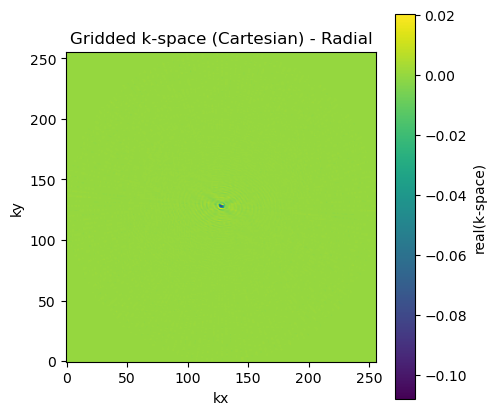

'cartesian_image_radial = sp.fft(kspace_cart)\npl.ImagePlot(cartesian_image_radial)'

In [9]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=0, undersampling_factor=1)
one_coil_zte = zte_radial_kspace[0]
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[...,1]**2)


#zte_radial_coords_reindexed = zte_radial_coords + 128


kspace_cart = sp.gridding(one_coil_zte * dcf, zte_radial_coords, shape=(256, 256))
#kspace_cart = np.fft.fftshift(kspace_cart)

plt.figure(figsize=(5, 5))
plt.imshow(np.real(np.fft.fftshift(kspace_cart)), cmap='viridis', origin='lower')
'''region = np.real(np.fft.fftshift(kspace_cart))
plt.imshow(region[108:148, 108:148], cmap='viridis', origin='lower')'''
plt.colorbar(label='real(k-space)')
plt.title('Gridded k-space (Cartesian) - Radial')
plt.xlabel('kx')
plt.ylabel('ky')
'''plt.xlim(108,148)
plt.ylim(108,148)'''
plt.show()

'''cartesian_image_radial = sp.fft(kspace_cart)
pl.ImagePlot(cartesian_image_radial)'''



(65.0, 175.0)

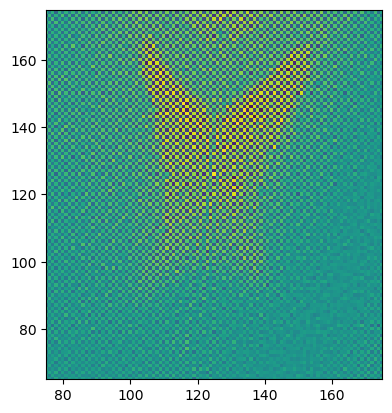

In [10]:
img = sp.fft(kspace_cart)
#pl.ImagePlot((img))
plt.imshow(np.real(img), cmap='viridis')
plt.xlim(75,175)
plt.ylim(65,175)

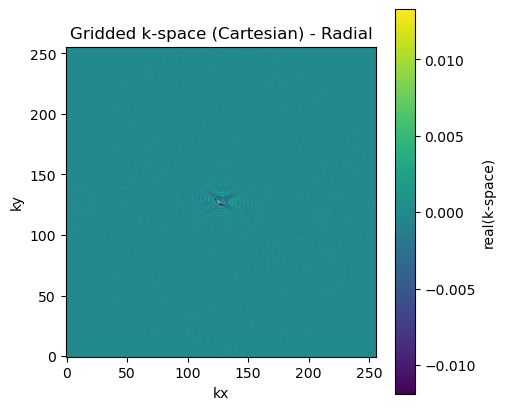

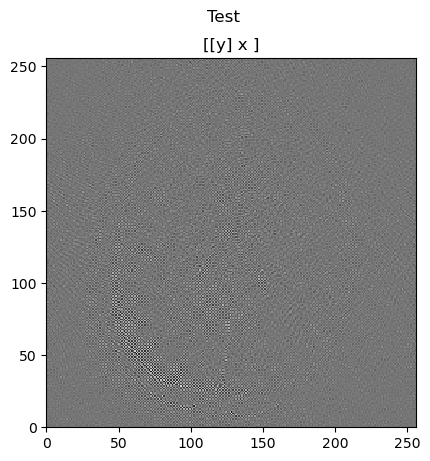

In [ ]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=5, undersampling_factor=1)
one_coil_zte = zte_radial_kspace[0]
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[...,1]**2)



kspace_cart = sp.gridding(one_coil_zte * dcf, zte_radial_coords, shape=(256, 256))
#kspace_cart = np.fft.fftshift(kspace_cart)

plt.figure(figsize=(5, 5))
plt.imshow(np.real(np.fft.fftshift(kspace_cart)), cmap='viridis', origin='lower')
'''region = np.real(np.fft.fftshift(kspace_cart))
plt.imshow(region[108:148, 108:148], cmap='viridis', origin='lower')'''
plt.colorbar(label='real(k-space)')
plt.title('Gridded k-space (Cartesian) - Radial')
plt.xlabel('kx')
plt.ylabel('ky')
'''plt.xlim(108,148)
plt.ylim(108,148)'''
plt.show()

'''cartesian_image_radial = sp.fft(kspace_cart)
pl.ImagePlot(cartesian_image_radial)'''


img_grid = sp.ifft((kspace_cart), axes=(-2, -1))
pl.ImagePlot(np.real(img_grid),title='Test')
#img_rss = np.sum(np.abs(img_grid)**2, axis=0)**0.5
#pl.ImagePlot(img_rss, title='12 coil root squares, gap=10')

### Goal: Extend Gridding with `sp.gridding` and `np.fft.fftshift` to 
a) single coil 
b) multi coil

1. gridding_one_coil - for testing/debugging
2. gridding_operator - for 

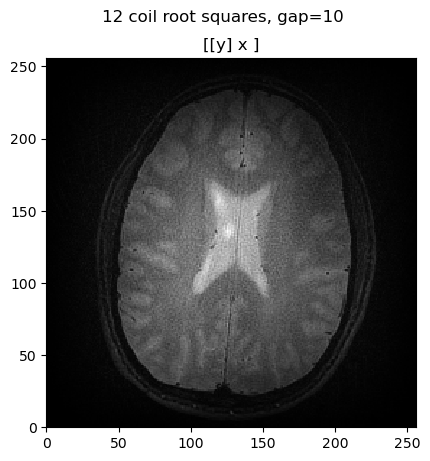

In [12]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=0, undersampling_factor=1)
def gridding_one_coil(kspace_data, coord):
    dcf = np.sqrt(coord[..., 0]**2 + coord[..., 1]**2)
    shape=(len(coord[1]), len(coord[1]))
    #coord_reindexed = coord + np.array(shape) // 2 
    kspace_cartesian = sp.gridding(kspace_data * dcf, coord, shape=shape,kernel='kaiser_bessel')
    kspace_cartesian = np.fft.fftshift(kspace_cartesian)
    return kspace_cartesian


def gridding_operator(kspace_data, coord):
    n_coils = kspace_data.shape[0]
    shape=(len(coord[1]), len(coord[1]))
    kspace_cartesian = np.zeros((n_coils, *shape), dtype=complex)
    
    dcf = np.sqrt(coord[..., 0]**2 + coord[..., 1]**2)
    

    
    for coil in range(n_coils):
        kspace_cartesian[coil] = sp.gridding(kspace_data[coil] * dcf, coord, shape=shape, kernel='kaiser_bessel')
        kspace_cartesian[coil] = np.fft.fftshift(kspace_cartesian[coil])
    
    return kspace_cartesian

a = gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

img_grid = sp.ifft(a)
#pl.ImagePlot(img_grid, z=0, title='Multi Channel Gridding')
img_rss = np.sum(np.imag(img_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss, title='12 coil root squares, gap=10')

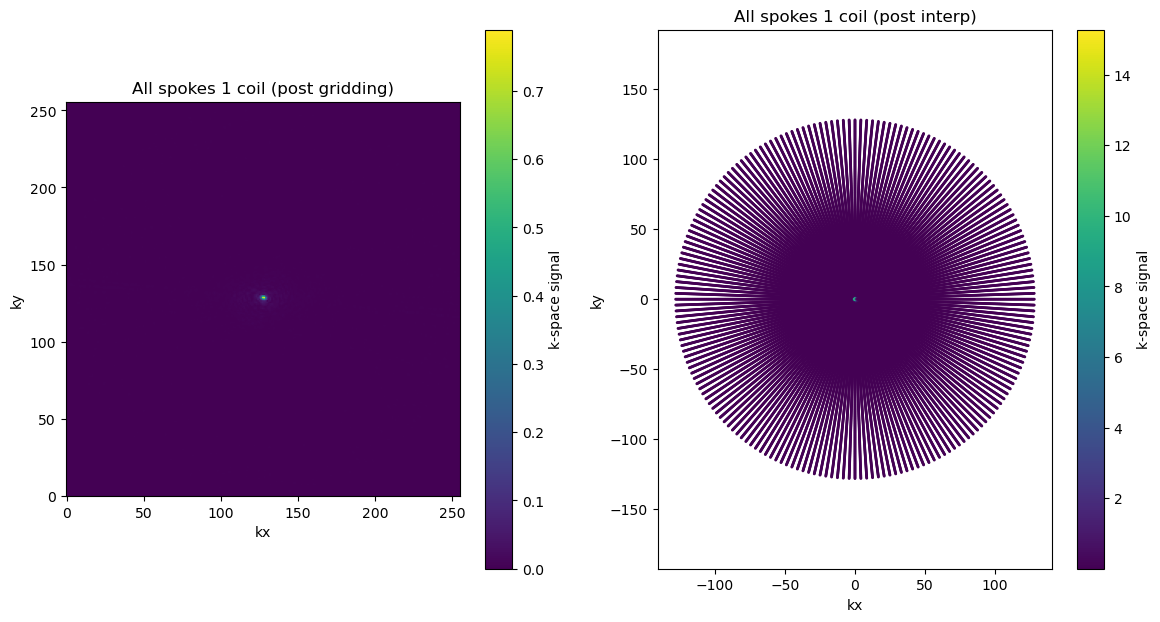

In [13]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=0, undersampling_factor=1)
ai = gridding_one_coil(zte_radial_kspace[0], coord=zte_radial_coords)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[...,1]**2)
aii = np.fft.ifftshift(ai)
b = sp.interpolate(aii, zte_radial_coords,kernel='kaiser_bessel') / dcf

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))


im0 = ax[0].imshow(np.abs(ai), cmap='viridis', origin='lower')
fig.colorbar(im0, ax=ax[0], label='k-space signal')
ax[0].set_title('All spokes 1 coil (post gridding)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')


sc = ax[1].scatter(all_coords[:, 0], all_coords[:, 1],c=np.abs(b), s=1, cmap='viridis')
fig.colorbar(sc, ax=ax[1], label='k-space signal')
ax[1].set_title('All spokes 1 coil (post interp)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')

plt.show()



In [14]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=0, undersampling_factor=1)
def gridding_operator_H(cartesian_data,coord):
    n_coils = cartesian_data.shape[0]
    spokes_points = coord.shape[:-1]
    kspace_data = np.zeros((n_coils, *spokes_points), dtype=complex)


    #dcf = np.sqrt(coord[..., 0]**2 + coord[..., 1]**2) #no longer needed
    for coil in range(n_coils):
        cartesian_data[coil] = np.fft.fftshift(cartesian_data[coil])
        kspace_data[coil] = sp.interpolate(cartesian_data[coil], coord)
    
    return kspace_data
ai2 = gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)
b = gridding_operator_H(cartesian_data=ai2,coord=zte_radial_coords)

In [15]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=0, undersampling_factor=1)
kspace_cart_coils = gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)
radial_interp_coils = gridding_operator_H(cartesian_data=kspace_cart_coils, coord=zte_radial_coords)
all_coords = zte_radial_coords.reshape(-1, 2)
'''plt.figure(figsize=(7, 7))
plt.scatter(all_coords[:, 0], all_coords[:, 1],c=np.abs(b[0]), s=1, cmap='viridis')
plt.colorbar(label='|k-space signal|')
plt.title('All spokes 1 coil (post interp)')
plt.xlabel('kx')
plt.ylabel('ky')
plt.axis('equal')
plt.show()'''

"plt.figure(figsize=(7, 7))\nplt.scatter(all_coords[:, 0], all_coords[:, 1],c=np.abs(b[0]), s=1, cmap='viridis')\nplt.colorbar(label='|k-space signal|')\nplt.title('All spokes 1 coil (post interp)')\nplt.xlabel('kx')\nplt.ylabel('ky')\nplt.axis('equal')\nplt.show()"

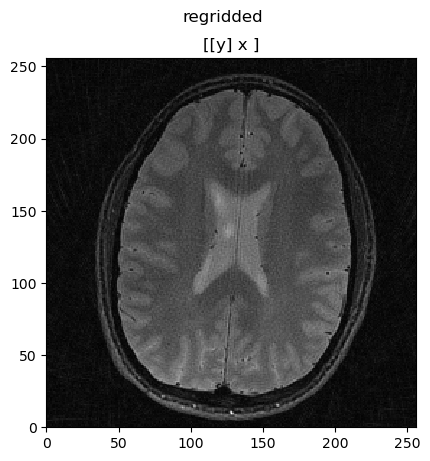

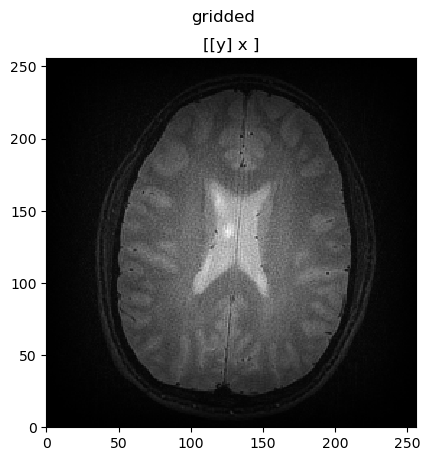

In [16]:
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid_griddedd = sp.nufft_adjoint(b * dcf, zte_radial_coords)
#pl.ImagePlot(zte_img_grid_griddedd, z=0)
img_rss_gridded = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss_gridded, title='regridded')


img_cart_grid = sp.ifft(kspace_cart_coils)
img_rss_cart = np.sum(np.abs(img_cart_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss_cart, title='gridded')

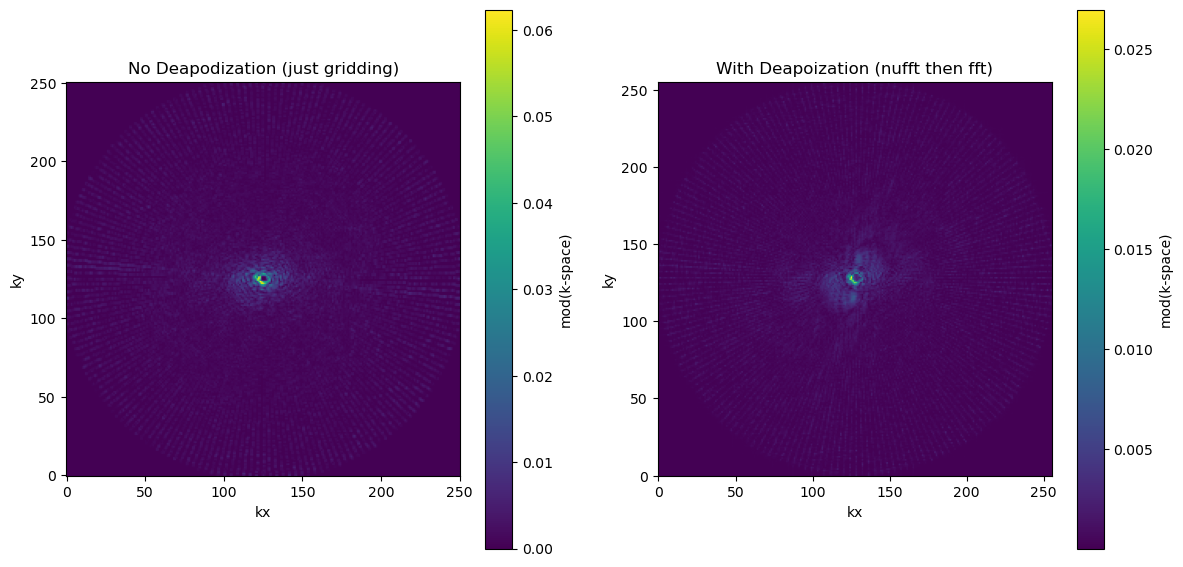

In [17]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp,coord=coord,n_missing=5, undersampling_factor=1)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)
zte_cart_kspace_imgtrip = sp.fft(zte_img_grid, axes=(-2, -1))

kspace_cart_coils = gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)



fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))


im0 = ax[0].imshow(np.abs(kspace_cart_coils[0]), origin='lower')
fig.colorbar(im0, ax=ax[0], label='mod(k-space)')
ax[0].set_title('No Deapodization (just gridding)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')


im1 = ax[1].imshow(np.abs(zte_cart_kspace_imgtrip[0]), origin='lower')
fig.colorbar(im1, ax=ax[1], label='mod(k-space)')
ax[1].set_title('With Deapoization (nufft then fft)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
#ax[1].axis('equal')

plt.show()